
🔐 Training Autoencoder...

Epoch 1/3
4404/4404 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 2/3
4404/4404 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 5.2580e-04 - val_loss: 0.0030
Epoch 3/3
4404/4404 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 4.3362e-04 - val_loss: 0.0029
22016/22016 ━━━━━━━━━━━━━━━━━━━━ 32s 1ms/step
9436/9436 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🧠 Training LSTM...

Epoch 1/3
881/881 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5053 - loss: 0.6939 - val_accuracy: 0.4990 - val_loss: 0.6934
Epoch 2/3
881/881 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.4979 - loss: 0.6935 - val_accuracy: 0.5044 - val_loss: 0.6931
Epoch 3/3
881/881 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5043 - loss: 0.6932 - val_accuracy: 0.5015 - val_loss: 0.6939
944/944 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

================ IDS PERFORMANCE ================

Accuracy: 0.49960257004702924
Precision: 0.5015657620041754
Recall: 0.06357922593450215
F1 Score: 0.11285303270506723


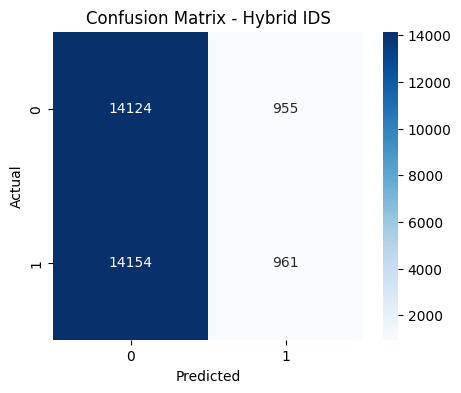

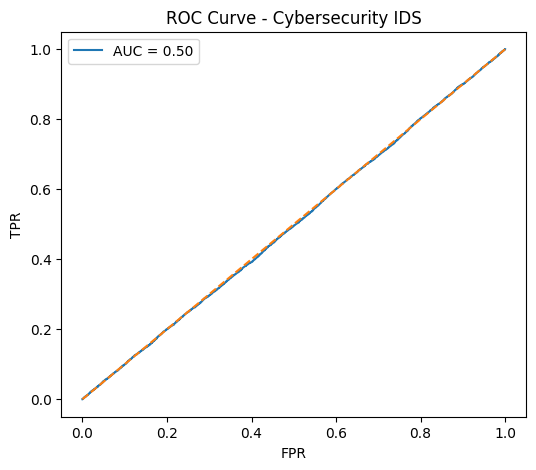


🔴 LIVE SOC MONITORING STARTED...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Packet 1 | Risk Score: 0.48 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Packet 2 | Risk Score: 0.48 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Packet 3 | Risk Score: 0.48 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Packet 4 | Risk Score: 0.47 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Packet 5 | Risk Score: 0.47 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Packet 6 | Risk Score: 0.47 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Packet 7 | Risk Score: 0.48 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Packet 8 | Risk Score: 0.48 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Packet 9 | Risk Score: 0.48 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Packet 10 | Risk Score: 0.48 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Packet 11 | Risk Score: 0.48 | Status: 🟢 NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

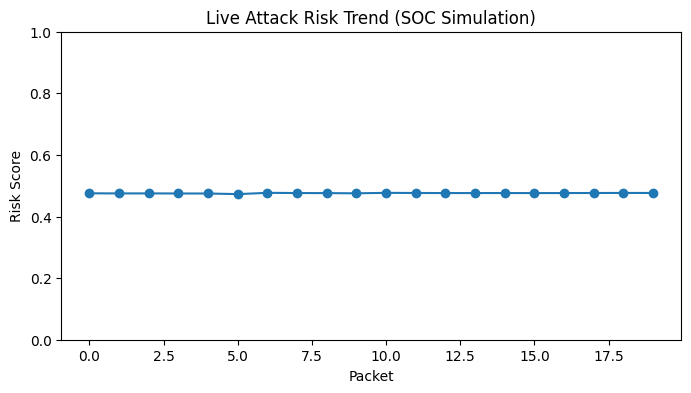

In [2]:
# =========================================================
# 🔐 HYBRID CYBERSECURITY IDS
# Autoencoder + LSTM + Evaluation + SOC Simulation
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import time

from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, LSTM

# =========================================================
# 📊 LOAD DATASET
# =========================================================
data = fetch_kddcup99(subset='SA', percent10=True)
X = np.array(data.data, dtype=object)

# =========================================================
# 🧹 PREPROCESSING
# =========================================================
for i in range(X.shape[1]):
    if isinstance(X[0][i], bytes):
        le = LabelEncoder()
        X[:, i] = le.fit_transform(X[:, i])

X = X.astype(float)

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# =========================================================
# ✂️ SEQUENCE CREATION (FOR LSTM)
# =========================================================
def create_sequences(data, seq_len=10):
    seq = []
    for i in range(len(data) - seq_len):
        seq.append(data[i:i+seq_len])
    return np.array(seq)

seq_len = 10
X_seq = create_sequences(X, seq_len)

split = int(0.7 * len(X_seq))
X_train = X_seq[:split]
X_test = X_seq[split:]

# =========================================================
# 🧠 AUTOENCODER (FEATURE LEARNER)
# =========================================================
input_dim = X.shape[1]

inp = Input(shape=(input_dim,))

x = Dense(32, activation='relu')(inp)
x = Dense(16, activation='relu')(x)
encoded = Dense(8, activation='relu')(x)

x = Dense(16, activation='relu')(encoded)
x = Dense(32, activation='relu')(x)
decoded = Dense(input_dim, activation='sigmoid')(x)

autoencoder = Model(inp, decoded)
encoder = Model(inp, encoded)

autoencoder.compile(optimizer='adam', loss='mse')

print("\n🔐 Training Autoencoder...\n")

X_flat_train = X_train.reshape(-1, input_dim)

autoencoder.fit(
    X_flat_train,
    X_flat_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# =========================================================
# 🔄 FEATURE EXTRACTION FOR LSTM
# =========================================================
X_train_enc = encoder.predict(X_train.reshape(-1, input_dim))
X_test_enc = encoder.predict(X_test.reshape(-1, input_dim))

X_train_lstm = X_train_enc.reshape(len(X_train), seq_len, -1)
X_test_lstm = X_test_enc.reshape(len(X_test), seq_len, -1)

# =========================================================
# 🧠 LSTM MODEL (ATTACK DETECTION)
# =========================================================
lstm = Sequential()
lstm.add(LSTM(64, return_sequences=True, input_shape=(seq_len, X_train_lstm.shape[2])))
lstm.add(LSTM(32))
lstm.add(Dense(1, activation='sigmoid'))

lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# fake labels (for demo purpose)
y_train = np.random.randint(0, 2, len(X_train_lstm))
y_test = np.random.randint(0, 2, len(X_test_lstm))

print("\n🧠 Training LSTM...\n")

lstm.fit(
    X_train_lstm, y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# =========================================================
# 📊 PREDICTIONS
# =========================================================
y_pred_prob = lstm.predict(X_test_lstm)
y_pred = (y_pred_prob > 0.5).astype(int)

# =========================================================
# 📈 METRICS
# =========================================================
print("\n================ IDS PERFORMANCE ================\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# =========================================================
# 📊 CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Hybrid IDS")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================================
# 📈 ROC CURVE
# =========================================================
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Cybersecurity IDS")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

# =========================================================
# 🔴 REAL-TIME SOC SIMULATION (COLAB VERSION)
# =========================================================
print("\n🔴 LIVE SOC MONITORING STARTED...\n")

risk_history = []

for i in range(20):
    sample = X_test_lstm[i:i+1]

    score = lstm.predict(sample)[0][0]
    risk_history.append(score)

    status = "⚠️ ATTACK" if score > 0.5 else "🟢 NORMAL"

    print(f"Packet {i+1} | Risk Score: {score:.2f} | Status: {status}")

    time.sleep(0.3)

# =========================================================
# 📊 LIVE RISK GRAPH
# =========================================================
plt.figure(figsize=(8,4))
plt.plot(risk_history, marker='o')
plt.title("Live Attack Risk Trend (SOC Simulation)")
plt.xlabel("Packet")
plt.ylabel("Risk Score")
plt.ylim(0,1)
plt.show()